In [1]:
import json
from pathlib import Path
from typing import overload, Callable

import numpy as np
from jaxtyping import Float, Int
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


In [3]:
def load_activations(
	model_name: str,
	base_path: Path = Path("../docs/demo"),
) -> tuple[
	dict,
	list[dict],
	list[np.lib.npyio.NpzFile],
]:
	"returns (model_config, prompts, activations)"
	model_path: Path = base_path / model_name

	# prompts
	with open(model_path / "prompts.jsonl") as f:
		prompts = [json.loads(line) for line in f]
	
	# activations
	activations: list[np.ndarray] = [
		np.load(model_path / "prompts" / p["hash"] / "activations.npz") for p in prompts
	]

	# model config
	model_config: dict = json.loads((model_path / "model_cfg.json").read_text())

	return model_config, prompts, activations


In [ ]:
MODEL_NAME: str = "pythia-14m"
MODEL_CFG: dict; PROMPTS: list[dict]; ACTIVATIONS: list[np.lib.npyio.NpzFile]
MODEL_CFG, PROMPTS, ACTIVATIONS = load_activations(MODEL_NAME)

def get_single_attn_pattern(
	sample: int,
	layer: int,
	head: int,
	activations=ACTIVATIONS,
) -> Float[np.ndarray, "n_ctx n_ctx"]:
	return activations[sample][f"blocks.{layer}.attn.hook_pattern"][0, head]

In [19]:
def cross_entropy(
	p: Float[np.ndarray, " d"],
	q: Float[np.ndarray, " d"],
) -> float:
	"$H(p,q)=-\sum _{x\in {\mathcal {X}}}p(x)\,\log q(x)$"
	return -np.sum(p * np.log(q))

def sigmoid(
	x: Float[np.ndarray, " d"], # input
	x0: float,     # x-value of the sigmoid's midpoint
	k: float,         # steepness of the sigmoid
	L: float = 1.0, 	   # curve's maximum value
	b: float = 0.0,        # curve's minimum value
) -> Float[np.ndarray, " d"]:
	"""Sigmoid function
	
	- `x: Float[np.ndarray, " d"]`
	  input
	- `x0: float`
	  x-value of the sigmoid's midpoint
	- `k: float`
	  steepness of the sigmoid
	- `L: float`
	  curve's maximum value
	  (default: `1.0`)
	- `b: float`
	  curve's minimum value
	  (default: `0.0`)
	
	"""	
	return L / (1 + np.exp(-k * (x - x0))) + b

In [ ]:


def transition_tensor(
	A: Float[np.ndarray, "n_ctx n_ctx"],
	exact: int = 10,
	approx_l10: int = 3,
	approx_pts: int = 20,
	res_norm: Callable[[Float[np.ndarray, "d"], Float[np.ndarray, "d"]], float] = cross_entropy,
) -> tuple[
	Int[np.ndarray, "n_idxs"],               # idxs
	Float[np.ndarray, "n_idxs n_ctx n_ctx"], # resampled transition tensor
	Float[np.ndarray, "n_idxs n_ctx"],       # resampled residuals
]:
	"""
	Compute the 3D transition tensor, residuals, and then resample
	
	- compute: `X` of shape `(K, n_ctx, n_ctx)` such that `X[t, i, j]` = Probability of being in state j at step k if we start in state i at step 0. `X[t, i, j] = A^t_[i, j]`
	- compute: `residuals` of shape `(K, n_ctx)` such that `residuals[t, i] = res_norm(X[t, i, :], X[t-1, i, :])`
	- resample both with the first `exact` points and then `approx_pts` points between `exact` and `approx_l10**10` on a log scale.

	# Parameters
	- `A: np.ndarray`
	    An n x n transition matrix (row-stochastic for a standard Markov chain).
	- `exact: int`
	    The number of exact points to include in the resampling.
	- `approx_l10: int`
	    The log base 10 of the maximum number of points to include in the resampling.
	- `approx_pts: int`
	    The number of points to include in the resampling between `exact` and `approx_l10**10`.

	# Returns
	- `idxs: Int[np.ndarray, "n_idxs"]`
	- `X: Float[np.ndarray, "n_idxs n_ctx n_ctx"]`
	    A 3D NumPy array of shape `(K, n, n)` such that:
	    - X[k, :, k] is A^(idxs[k]) for k >= 1.
	    - X[0, :, :] is the identity matrix (k=0).
	- `residuals: Float[np.ndarray, "n_idxs n_ctx"]`
	    A 2D NumPy array of shape `(K, n)` such that:
	    - residuals[k, i] is the residual between X[k, i, :] and X[k-1, i, :].
		- residuals[0, i] is NaN.
	"""
	max_K: int = np.power(10, approx_l10)
	assert max_K > exact, "approx_l10 must be greater than exact"

	# compute original transition tensor
	n: int = A.shape[0]
	X: Float[np.ndarray, "K n_ctx n_ctx"] = np.full((2, n, n, max_K), fill_value=np.nan, dtype=A.dtype)
	X[0, :, :] = np.eye(n, dtype=A.dtype)

	# Compute powers of A iteratively
	# TODO: do this more cleverly
	for t in range(1, max_K):
		X[t, :, :] = X[t-1, :, :] @ A

	# compute residuals
	residuals: Float[np.ndarray, "n_idxs n_ctx"] = np.full((max_K, n), fill_value=np.nan, dtype=A.dtype)
	residuals[1:, :] = np.abs(X[1:, :, :] - X[:-1, :, :])

	# resample
	resampled_idxs: Int[np.ndarray, "approx_pts"] = np.logspace(np.log10(exact), approx_l10, approx_pts, base=10, dtype=int)
	idxs: Int[np.ndarray, "n_idxs"] = np.concatenate([np.arange(exact), resampled_idxs])
	n_idxs: int = len(idxs)	

	tt_resampled: Float[np.ndarray, "n_idxs n_ctx n_ctx"] = X[idxs, :, :]
	res_resampled: Float[np.ndarray, "n_idxs n_ctx"] = residuals[idxs, :]

	return idxs, tt_resampled, res_resampled 

C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(sigmoid, x, y, p0=p0)
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: invalid value encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(sigmoid, x, y, p0=p0)
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[

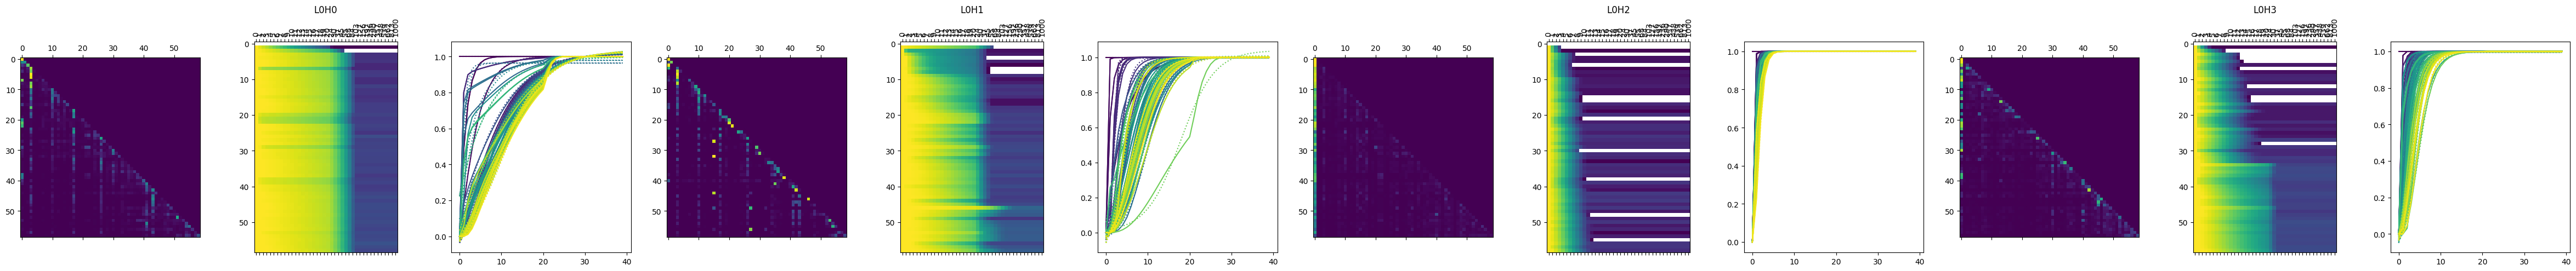

C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: invalid value encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(sigmoid, x, y, p0=p0)
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: invalid value encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:29: OptimizeWarning: Covariance of the parameters could not be estimate

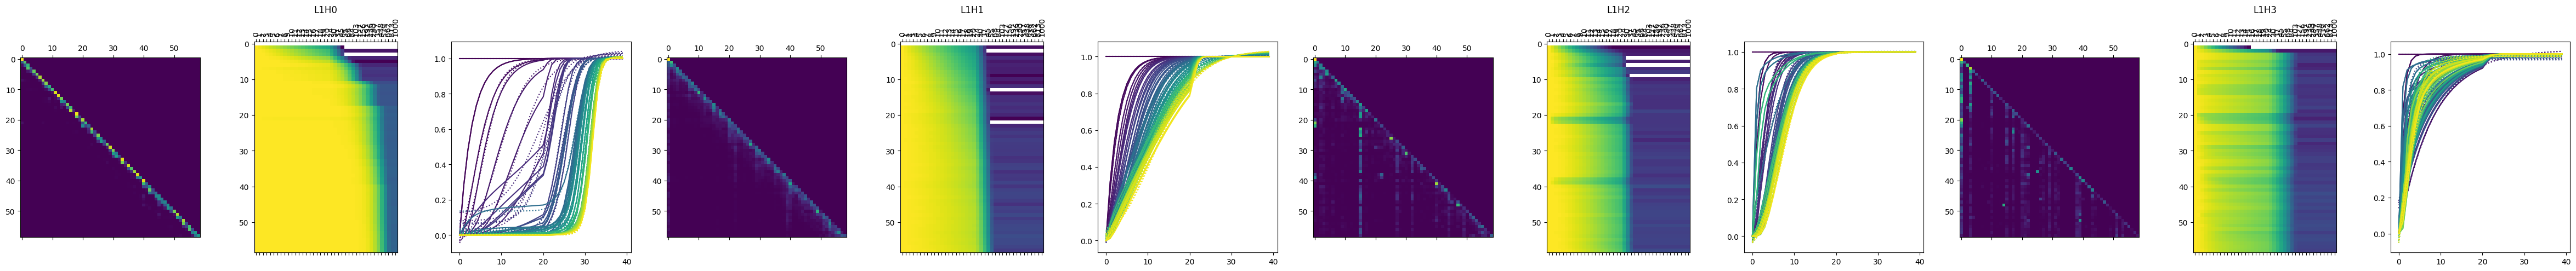

C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: invalid value encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(sigmoid, x, y, p0=p0)
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(sigmoid, x, y, p0=p0)
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[

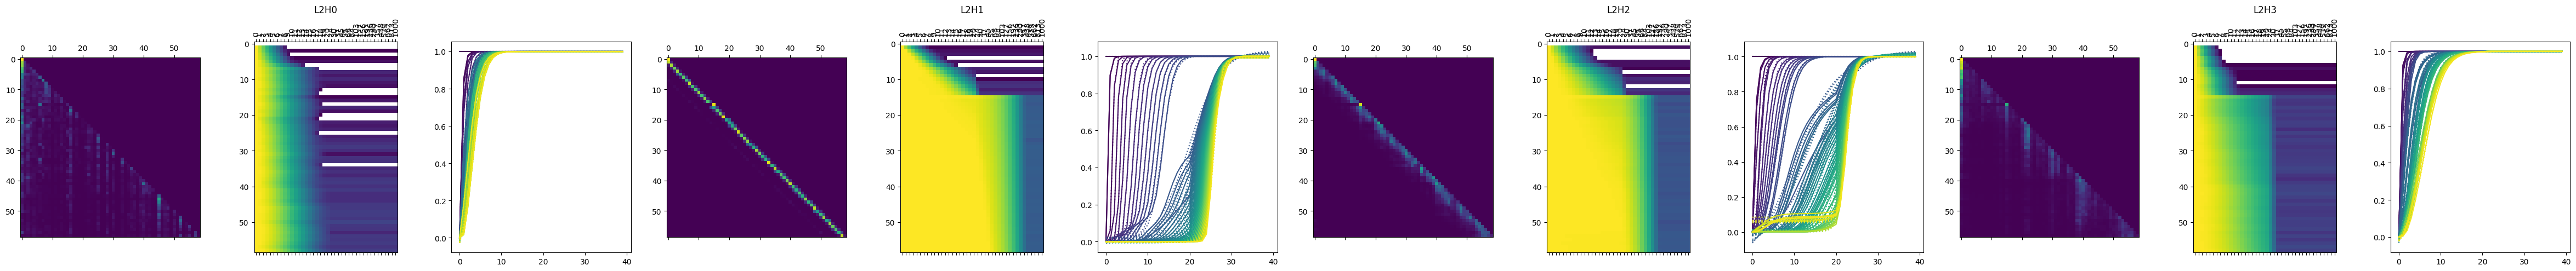

C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: invalid value encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(sigmoid, x, y, p0=p0)
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: invalid value encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:29: OptimizeWarning: Covariance of the parameters could not be estimate

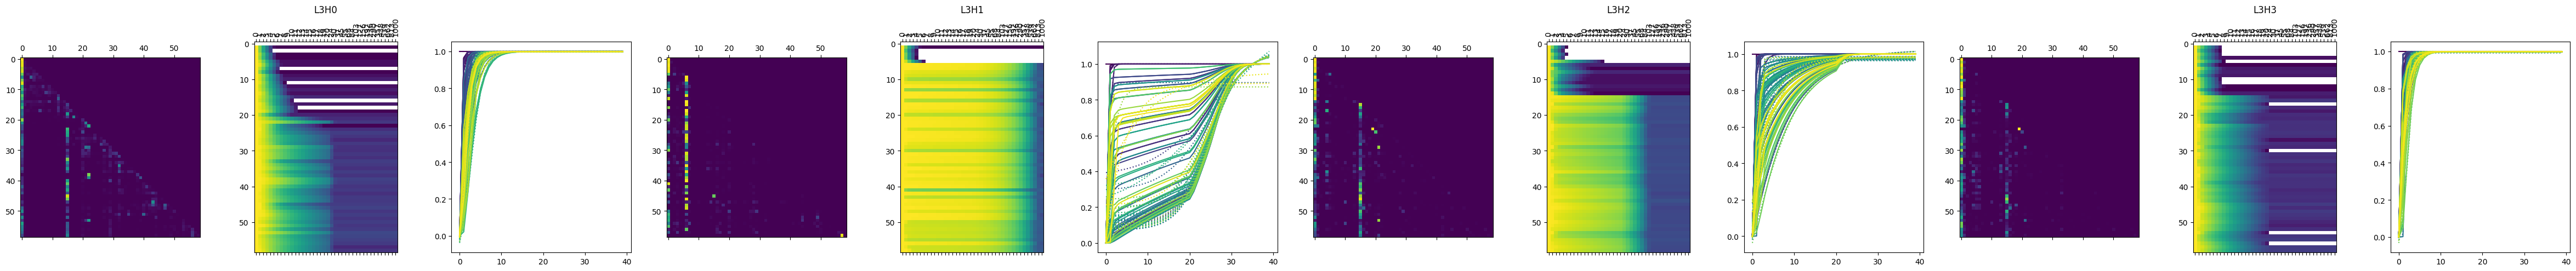

C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: invalid value encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(sigmoid, x, y, p0=p0)
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: invalid value encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:29: OptimizeWarning: Covariance of the parameters could not be estimate

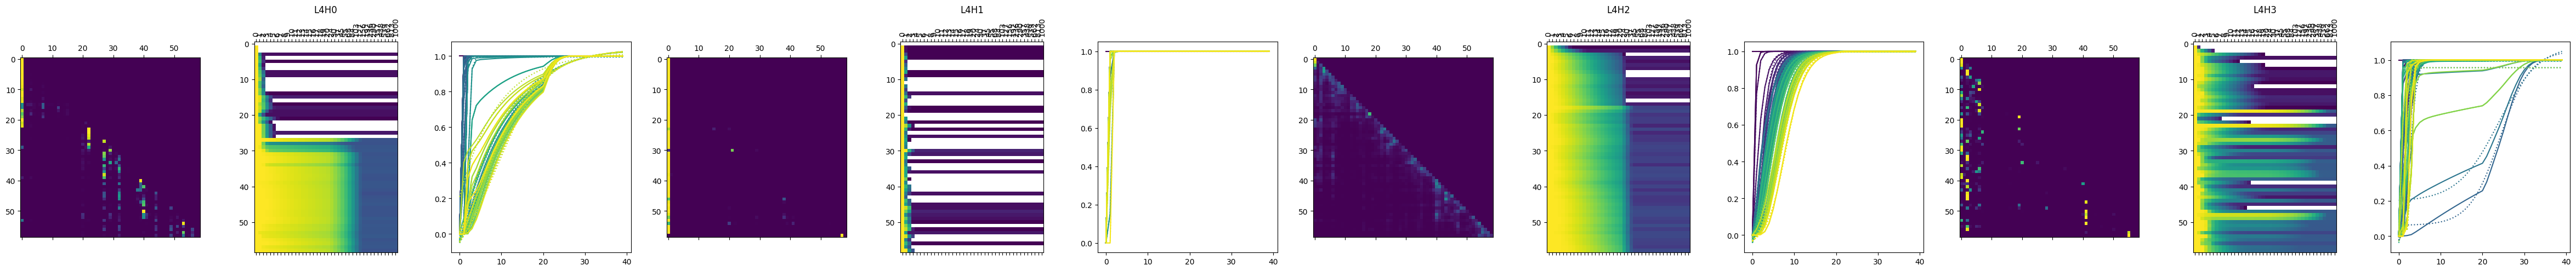

C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(sigmoid, x, y, p0=p0)
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: invalid value encountered in log10
  axs[p*head + 1].matshow(np.log10(1 - tt[:, 0, :]))
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(sigmoid, x, y, p0=p0)
C:\Users\mivan\AppData\Local\Temp\ipykernel_1544\2525945763.py:13: RuntimeWarning: divide by zero encountered in log10
  axs[

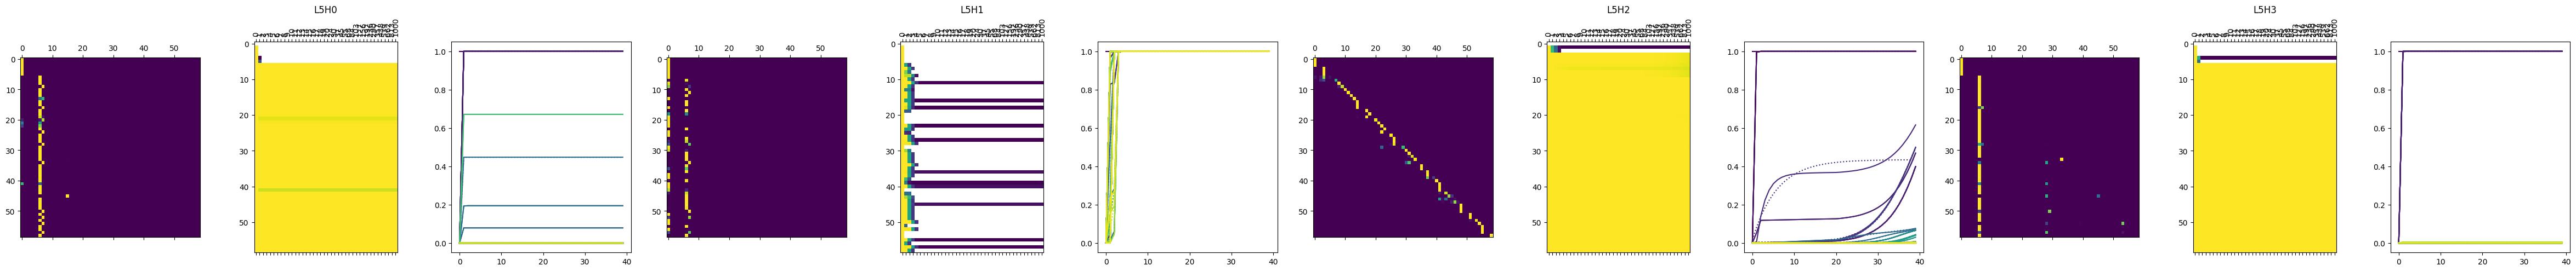

In [41]:
def plot_figs(
	n_figures: int,
	figure_func: Callable,
	prompts: list[int] = None,
	layers: list[int]|None = None,
	heads: list[int]|None = None,
	model_cfg: dict = MODEL_CFG,
	prompt_dicts: list[dict] = PROMPTS,
	activations: list[np.lib.npyio.NpzFile] = ACTIVATIONS,
):
	
	n_lyrs: int = model_cfg["n_layers"]
	n_heads: int = model_cfg["n_heads"]

	if layers is None:
		layers = list(range(n_lyrs))

	if heads is None:
		heads = list(range(n_heads))

	if prompts is None:
		prompts = list(range(len(prompt_dicts)))

	for p_idx in prompts:
		for lyr in range(n_lyrs): 
			for head in range(n_heads):
				fig, axs = plt.subplots(1, n_figures, figsize=(n_figures*5, 5))
				A = get_single_attn_pattern(p_idx, lyr, head)				
				figure_func(A, axs, p_idx, lyr, head)
				prompt: dict = prompt_dicts[p_idx]
				fig.suptitle(f"model {model_cfg['model_name']} L{lyr}H{head}, prompt {p_idx}\n{prompt['hash'] = }, {prompt['n_tokens'] = }")
				plt.show()
				
				
				
def fig(
	A: np.ndarray,
	axs: np.ndarray,
	p_idx: int,
	lyr: int,
	head: int,
):
	#
	axs[0].set_title(f"raw attention")
	axs[0].matshow(A)

	# compute transition_tensor
	idxs, tt, res = transition_tensor(A, exact=20, approx_l10=3.0, approx_pts=20)

	#
	axs[1].set_title(f"transition tensor")
	axs[1].matshow(np.log10(1 - tt[:, 0, :]))
	axs[1].set_xticks(range(len(idxs)))
	axs[1].set_xticklabels(idxs)
	axs[1].tick_params(axis='x', rotation=90)
	
	#
	axs[2].set_title(f"transition curves")
	cmap = plt.get_cmap('viridis')
	for i in range(tt.shape[0]):
		axs[2].plot(tt[i, 0, :], label=f"i={i}", color=cmap(i / tt.shape[0]))
		x: np.ndarray = np.arange(tt.shape[2])
		y: np.ndarray = tt[i, 0, :]
		# Initial parameter guess: amplitude, midpoint, steepness, baseline
		p0: list[float] = [max(y) - min(y), np.median(x), 1.0, min(y)]
		try:
			popt: np.ndarray
			popt, _ = curve_fit(sigmoid, x, y, p0=p0)
			y_fit: np.ndarray = sigmoid(x, *popt)
			axs[2].plot(x, y_fit, ":", label=f"i={i} fit", color=cmap(i / tt.shape[0]))
		except Exception as e:
			# Fallback: plot raw data if the fit fails
			axs[2].plot(x, y, label=f"i={i}", color=cmap(i / tt.shape[0]))

	# 
	axs[3].set_title(f"residuals tensor")
	axs[3].matshow(res)
	axs[3].set_xticks(range(len(idxs)))
	axs[3].set_xticklabels(idxs)
	axs[3].tick_params(axis='x', rotation=90)

	#
	axs[4].set_title(f"residuals curves")
	for i in range(res.shape[0]):
		axs[4].plot(res[i, :], label=f"i={i}")
		axs[4].set_xticks(range(len(idxs)))
		axs[4].set_xticklabels(idxs)
		axs[4].tick_params(axis='x', rotation=90)

plot_figs(5, fig, prompts=[0], layers=[0], heads=[0])
	
plt.show()

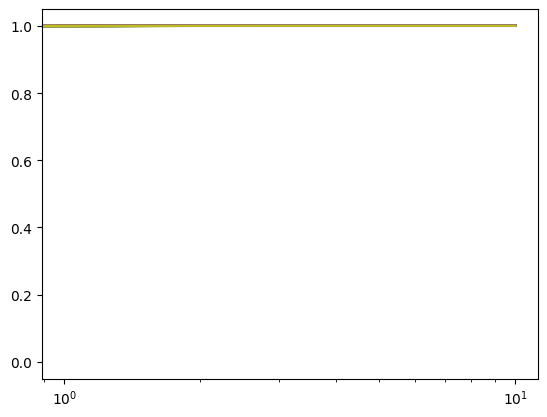

In [26]:
for lyr in range(n_lyrs): 
	fig, axs = plt.subplots(1, n_heads, figsize=(15, 5))
	for head in range(n_heads):
		for i in range(T.shape[0]):
			A = get_single_attn_pattern(lyr, head, 0)
			axs[2*head].matshow(A)
			idxs, tt = resampled_tt(A, exact=20, approx_l10=3.0, approx_pts=20)
			axs[head].plot(T[i, 0, :], label=f"i={i}")
# plt.legend()
plt.xscale("log")
# plt.yscale("log")
plt.show()

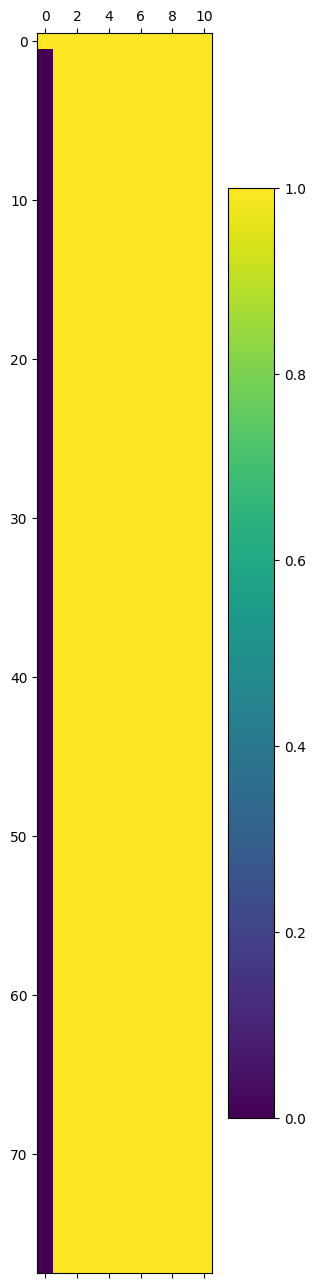

In [8]:
T_resample = tt
T = tt

plt.matshow(T_resample[:, 0, :])
plt.colorbar()
plt.show()

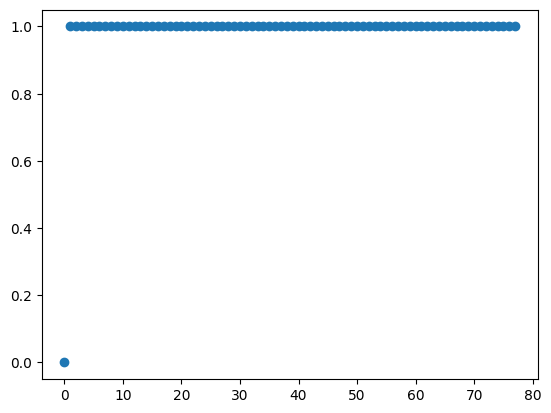

f:\projects\attention-motifs\.venv\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
f:\projects\attention-motifs\.venv\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


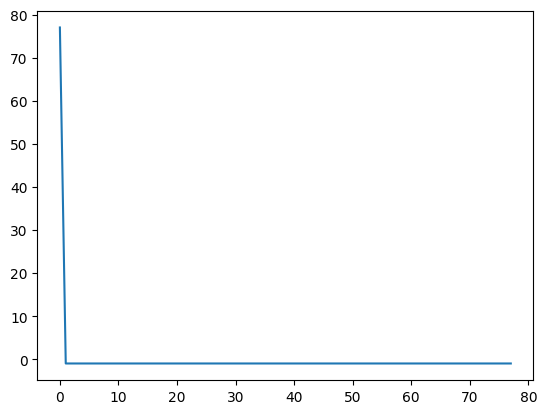

In [9]:
ttl = np.argmax(T[:, 0, :] > 0.9, axis=1)
ttl.shape
plt.plot(ttl, "o")
plt.show()

plt.plot(np.fft.fft(ttl))
plt.show()

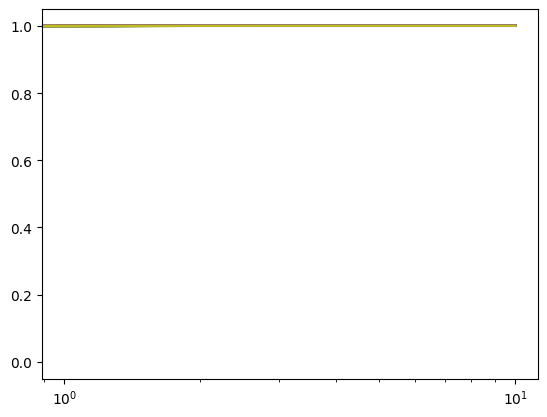

In [10]:
for i in range(n):
	plt.plot(T[i, 0, :], label=f"i={i}")
# plt.legend()
plt.xscale("log")
# plt.yscale("log")
plt.show()

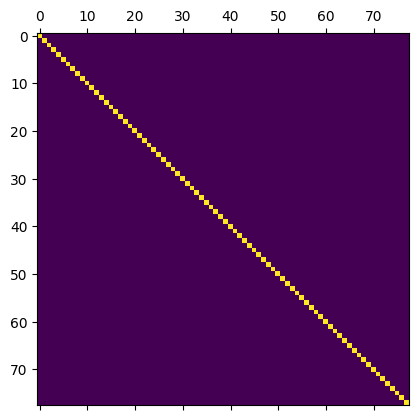

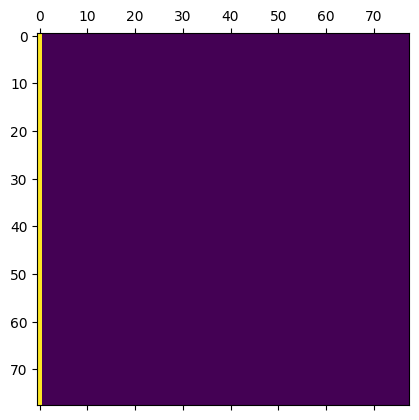

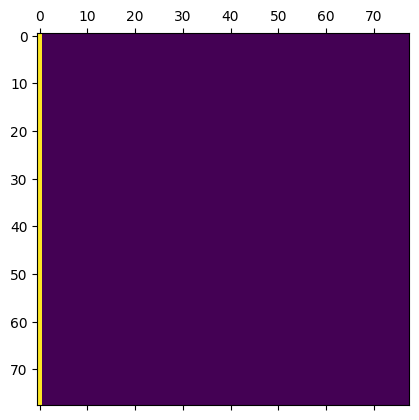

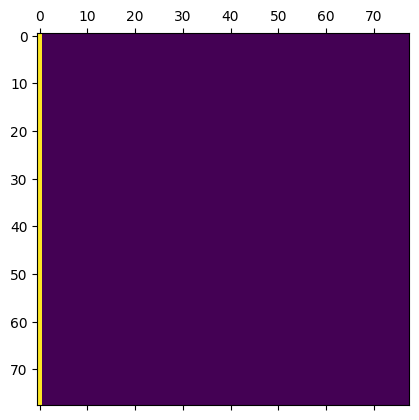

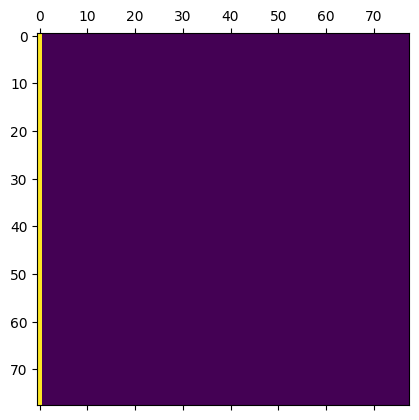

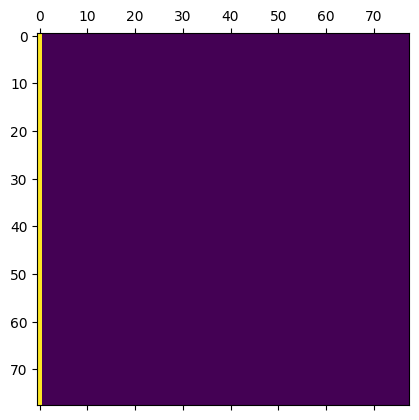

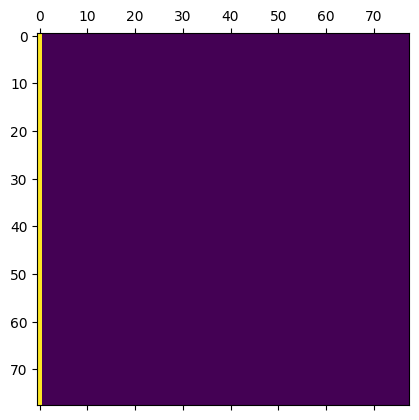

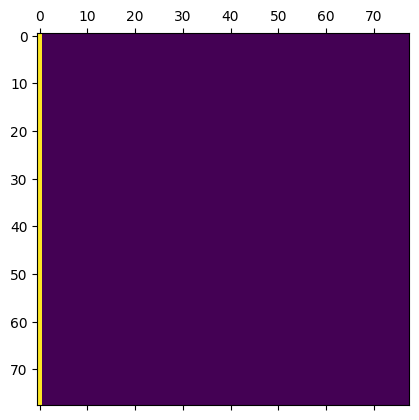

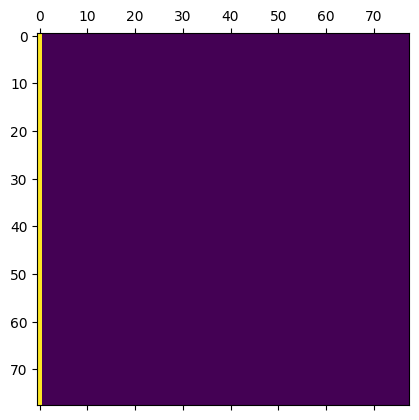

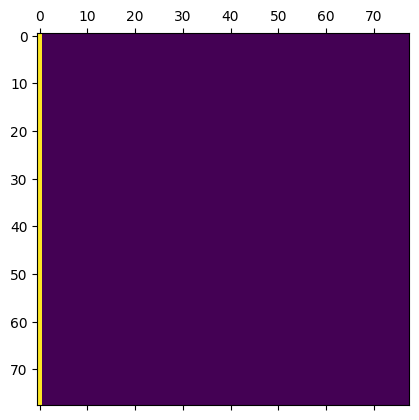

In [11]:
for i in range(10):
	plt.matshow(T[:, :, i])
	plt.show()